In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("financial_data.csv")

In [3]:
df = df.dropna(subset=["Görüs Tipi"])

In [4]:
df["risk"] = df["Görüs Tipi"].map({
    "Olumlu":0,
    "Şartlı":1,
    "Olumsuz":1,
    "Görüş bildirmekten kaçınma":1
})

In [5]:
cols_to_drop = ['Şirket Adı', 'Şirketin Kodu',"Görüs Tipi"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [6]:
df['Periyot'] = df['Periyot'].astype(str).str.replace(r'(?i)yıllık', '12', regex=True)
df['Periyot'] = (df['Periyot'].str.extract(r'^\s*(\d+)', expand=False).astype(float))
df['Periyot'] = df['Periyot'].astype('Int64')

In [7]:
df.shape

(10751, 51)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10751 entries, 0 to 27296
Data columns (total 51 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Periyot                                10751 non-null  Int64  
 1   Yıl                                    10751 non-null  int64  
 2   Dönen Varlıklar                        10751 non-null  float64
 3   Duran Varlıklar                        10751 non-null  float64
 4   Toplam Varlıklar                       10751 non-null  float64
 5   Kısa Vadeli Yükümlülükler              10751 non-null  float64
 6   Uzun Vadeli Yükümlülükler              10751 non-null  float64
 7   Toplam Yükümlülükler                   10751 non-null  float64
 8   Toplam Özkaynaklar                     10751 non-null  float64
 9   Ana Ortaklığa Ait Özkaynaklar          10751 non-null  float64
 10  Kontrol Gücü Olmayan Kaynaklar         10751 non-null  float64
 11  Toplam 

In [9]:
df.describe()

,Periyot,Yıl,Dönen Varlıklar,Duran Varlıklar,Toplam Varlıklar,Kısa Vadeli Yükümlülükler,Uzun Vadeli Yükümlülükler,Toplam Yükümlülükler,Toplam Özkaynaklar,Ana Ortaklığa Ait Özkaynaklar,...,Alacak Devir Hızı,Dönen Varlıklar Devir Hızı,Ticari Borçlar Devir Hızı,Finansal Kaldıraç,Stok Devir Hızı,Altman Z-Skoru,Springate Skoru,Zmijewski Skoru,L Model Skoru,risk
count,10751.0,10751.000000,1.075100e+04,1.075100e+04,1.075100e+04,1.075100e+04,1.075100e+04,1.075100e+04,1.075100e+04,1.075100e+04,...,1.075100e+04,10751.000000,1.075100e+04,10751.000000,10751.000000,10751.000000,10751.000000,10751.000000,10751.000000,10751.000000
mean,8.85713,2017.186866,4.646752e+09,5.249461e+09,9.898487e+09,4.514385e+09,1.725026e+09,6.238619e+09,3.656460e+09,3.137975e+09,...,5.813543e+04,6.523026,1.612824e+03,47.601740,233.614220,10.237253,1.935776,-1.748363,-1.034346,0.106130
std,3.064008,4.576498,5.548249e+10,4.367532e+10,9.722441e+10,6.388667e+10,1.393628e+10,7.542026e+10,2.450668e+10,1.885781e+10,...,4.443418e+06,143.136386,9.306397e+04,37.086572,6903.801021,72.078331,95.608336,2.473909,6.004654,0.308018
min,3.0,2008.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.534919e+09,-3.534919e+09,...,-4.590873e+03,-4609.293769,-5.467120e-04,0.000000,0.000000,-54.911580,-7824.796078,-51.341690,-290.759570,0.000000
25%,6.0,2013.000000,4.498157e+07,4.133044e+07,1.207695e+08,2.359916e+07,4.928540e+06,3.777167e+07,5.030656e+07,4.906845e+07,...,1.766789e+00,0.510006,1.880005e+00,24.964397,0.652023,0.945217,0.131935,-3.083074,-0.532258,0.000000
50%,9.0,2017.000000,2.129633e+08,2.106367e+08,5.336158e+08,1.384960e+08,4.080865e+07,2.133714e+08,2.346338e+08,2.250773e+08,...,3.538512e+00,0.895570,3.740859e+00,45.335738,2.668648,1.940658,0.589985,-1.797612,-0.409294,0.000000
75%,12.0,2021.000000,1.091638e+09,1.230043e+09,2.624552e+09,7.642501e+08,2.949599e+08,1.192861e+09,1.136350e+09,1.069240e+09,...,7.472896e+00,1.658008,7.405105e+00,66.631577,6.102530,3.558624,1.214186,-0.519714,-0.321916,0.000000
max,12.0,2024.000000,2.470000e+12,1.660000e+12,4.130000e+12,2.690000e+12,4.600000e+11,3.150000e+12,9.740000e+11,6.800000e+11,...,4.390772e+08,11246.527470,7.021669e+06,982.712377,335372.431100,3423.754076,5412.225556,49.602209,1.269018,1.000000


<Axes: xlabel='risk', ylabel='count'>

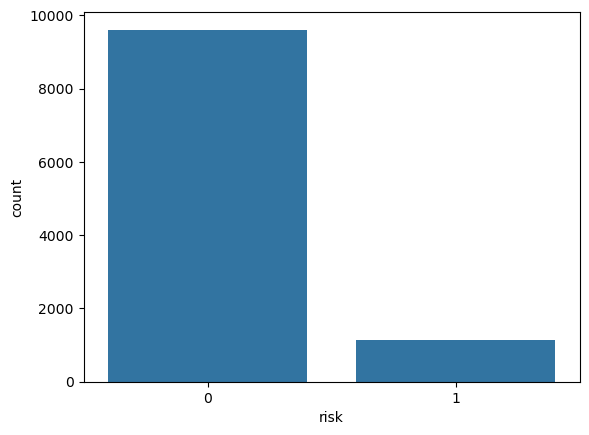

In [10]:
sns.countplot(x="risk", data=df)

In [11]:
col_names = df.columns

<Axes: >

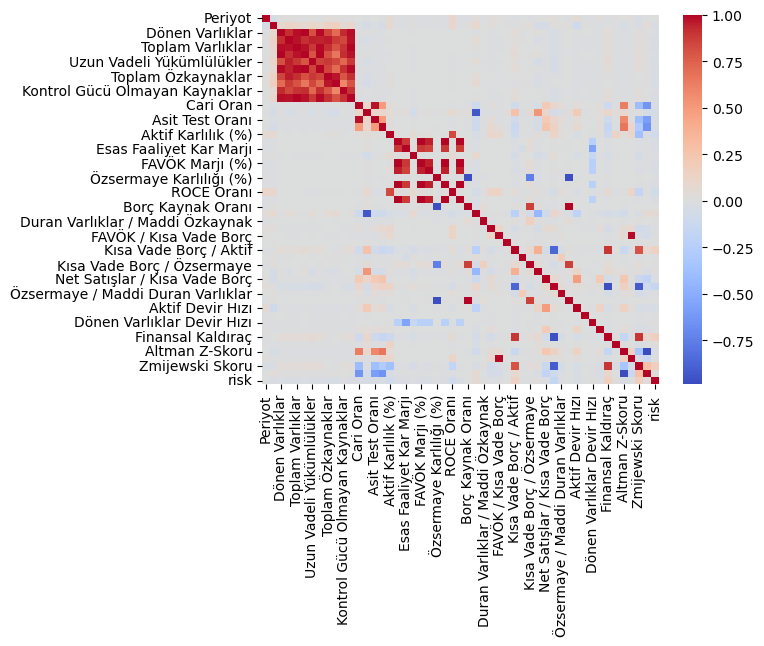

In [12]:
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm")

In [15]:
y=df["risk"]
X = df.drop(columns=["risk"])

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
model = RandomForestClassifier()
model.fit(X,y)

RandomForestClassifier()

In [18]:
importances = model.feature_importances_

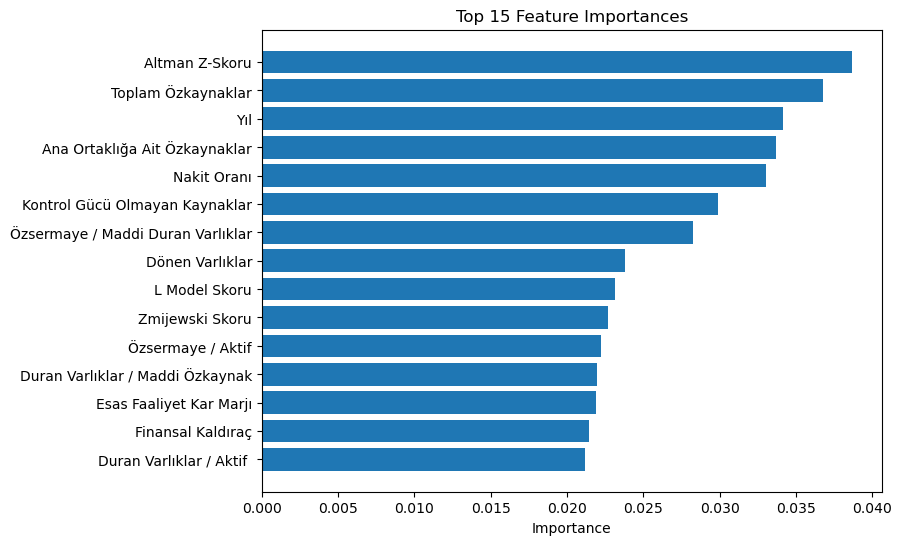

In [23]:
indices = np.argsort(importances)[::-1]
top_n = 15  

plt.figure(figsize=(8,6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], align='center')
plt.yticks(range(top_n), X.columns[indices[:top_n]][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.show()